In [1]:
import numpy as np
import pandas as pd
import os
import sys
import pandas as pd

## Task 0 - Load data

In [2]:
crops = pd.read_csv('data/FAOSTAT_crops.csv')
df_faostat_prices = pd.read_csv("data/FAOSTAT_prices.csv")

In [3]:
def crops_format(df, name):
    df = crops[crops['Item'] == name]
    df = df[['Area', 'Unit', 'Element', 'Item', 'Year', 'Value']]
    df_ = pd.pivot_table(df, index=['Item', 'Year'], columns='Element', values='Value').reset_index()
    df_ = df_.rename(columns={'Year': 'date'})
    df_ = df_[['Item', 'date', 'Area harvested', 'Yield', 'Production']]
    return df_

grapes = crops_format(crops, "Grapes")
print(grapes.head(10))
tomatoes = crops_format(crops, "Tomatoes")
print(tomatoes.head(10))
wheat = crops_format(crops, "Wheat")
print(wheat.head(10))
maize = crops_format(crops, "Maize (corn)")
print(maize.head(10))
sunflower = crops_format(crops, "Sunflower seed")
print(sunflower.head(10))

Element    Item  date  Area harvested   Yield  Production
0        Grapes  1980       1657400.0  4055.4   6721400.0
1        Grapes  1981       1657000.0  3260.4   5402503.0
2        Grapes  1982       1658000.0  3635.7   6028000.0
3        Grapes  1983       1645330.0  3111.3   5119100.0
4        Grapes  1984       1587250.0  3548.4   5632200.0
5        Grapes  1985       1552387.0  3510.9   5450240.0
6        Grapes  1986       1531200.0  3828.7   5862500.0
7        Grapes  1987       1514000.0  4204.0   6364800.0
8        Grapes  1988       1439900.0  2611.6   3760400.0
9        Grapes  1989       1434900.0  3508.0   5033600.0
Element      Item  date  Area harvested    Yield  Production
0        Tomatoes  1980         60700.0  35375.6   2147300.0
1        Tomatoes  1981         59600.0  36223.2   2158900.0
2        Tomatoes  1982         59300.0  38059.0   2256900.0
3        Tomatoes  1983         59600.0  39406.0   2348600.0
4        Tomatoes  1984         65100.0  38567.7   251075

Unités de mesure :
- Yield (in kg/ha)
- Production (in t)
- Area harvested (in ha)



Répartition de la ferme :

- total = 70 ha
- 10% tomatoes
- 20% sunflower
- 30% maize
- 10% grapes
- 30% wheat

In [4]:
SPI = pd.read_csv('data/SPI.csv')



SPI['time'] = pd.to_datetime(SPI['time'])

SPI = SPI.rename(columns={'SPI3': 'SPI'})

SPI['year'] = SPI['time'].dt.year
SPI_index = SPI.groupby('year')['SPI'].mean().reset_index()
SPI_index = SPI_index.rename(columns={'year': 'date'})

# Formater la date avec l'année-mois-jour heure (01-01 00:00:00)
SPI_index['date'] = pd.to_datetime(SPI_index['date'].astype(str))
print(SPI_index.head(10))

        date       SPI
0 1980-01-01  0.696258
1 1981-01-01  0.583559
2 1982-01-01  0.457449
3 1983-01-01 -0.535935
4 1984-01-01  1.113628
5 1985-01-01  0.072208
6 1986-01-01 -0.610300
7 1987-01-01 -0.185411
8 1988-01-01  1.306129
9 1989-01-01  1.614868


In [5]:
df_faostat_prices = df_faostat_prices.loc[:,["Item Code (CPC)", "Item", "Year", "Unit", "Value"]]
df_faostat_prices.rename(columns={"Year": "date"}, inplace=True)

In [6]:
grapes_prices = df_faostat_prices[df_faostat_prices["Item"] == "Grapes"].drop(columns=["Item Code (CPC)"])
maize_prices = df_faostat_prices[df_faostat_prices["Item"] == "Maize (corn)"].drop(columns=["Item Code (CPC)"])
sunflower_prices = df_faostat_prices[df_faostat_prices["Item"] == "Sunflower seed"].drop(columns=["Item Code (CPC)"])
tomatoes_prices = df_faostat_prices[df_faostat_prices["Item"] == "Tomatoes"].drop(columns=["Item Code (CPC)"])
wheat_prices = df_faostat_prices[df_faostat_prices["Item"] == "Wheat"].drop(columns=["Item Code (CPC)"])


In [7]:
def merge_price(df, price_df):
    df = pd.merge(df, price_df[['date', 'Value']], on='date', how='left')
    df = df.rename(columns={'Value': 'Price'})
    df.dropna(inplace=True)
    return df

grapes = merge_price(grapes, grapes_prices)
tomatoes = merge_price(tomatoes, tomatoes_prices)
wheat = merge_price(wheat, wheat_prices)
maize = merge_price(maize, maize_prices)
sunflower = merge_price(sunflower, sunflower_prices)

In [8]:
ipampa_overall_index = pd.read_csv("data/IPAMPA_overall_index.csv", sep=";")
ipampa_overall_index.rename(columns={"Label": "date", "Annual agricultural means of production purchasing price index (IPAMPA) - Overall index": "IPAMPA_overall_index"}, inplace=True)
print(ipampa_overall_index.head(10))

   date  IPAMPA_overall_index
0  2025                 124.7
1  2024                 125.4
2  2023                 131.2
3  2022                 133.7
4  2021                 109.2
5  2020                 100.0
6  2019                 101.7
7  2018                 100.2
8  2017                  96.7
9  2016                  95.5


## Task 1
#### Calul des revenus (outputs)


In [9]:
weights = {"Grapes": 0.2, "Maize (corn)": 0.2, "Sunflower seed": 0.2, "Tomatoes": 0.2, "Wheat": 0.2}
total = 70 #ha
ha_grapes = 70* weights["Grapes"]
ha_maize = 70* weights["Maize (corn)"]
ha_sunflower = 70* weights["Sunflower seed"]
ha_tomatoes = 70* weights["Tomatoes"]
ha_wheat = 70* weights["Wheat"]

In [10]:
grapes["Yield_tot"] = grapes["Yield"] * ha_grapes * 0.001 #en tonnes
maize["Yield_tot"] = maize["Yield"] * ha_maize * 0.001 #en tonnes
sunflower["Yield_tot"] = sunflower["Yield"] * ha_sunflower * 0.001 #en tonnes
tomatoes["Yield_tot"] = tomatoes["Yield"] * ha_tomatoes * 0.001 #en tonnes
wheat["Yield_tot"] = wheat["Yield"] * ha_wheat * 0.001 #en tonnes
print(grapes.head(10))

      Item  date  Area harvested   Yield  Production  Price  Yield_tot
11  Grapes  1991       1378892.0  3769.0   5197000.0  528.4    52.7660
12  Grapes  1992       1309169.0  4397.7   5757300.0  532.6    61.5678
13  Grapes  1993       1235000.0  3698.5   4567600.0  411.1    51.7790
14  Grapes  1994       1192600.0  2728.8   3254360.0  564.8    38.2032
15  Grapes  1995       1160100.0  2887.8   3350100.0  735.4    40.4292
16  Grapes  1996       1122400.0  4431.2   4973600.0  495.0    62.0368
17  Grapes  1997       1126989.0  4901.0   5523400.0  651.1    68.6140
18  Grapes  1998       1117900.0  4604.0   5146810.0  542.3    64.4560
19  Grapes  1999       1115282.0  5028.0   5607660.0  485.4    70.3920
20  Grapes  2000       1167703.0  5600.6   6539812.0  402.7    78.4084


In [11]:
grapes["Revenue"] = grapes["Yield_tot"] * grapes["Price"]
wheat["Revenue"] = wheat["Yield_tot"] * wheat["Price"]
maize["Revenue"] = maize["Yield_tot"] * maize["Price"]
sunflower["Revenue"] = sunflower["Yield_tot"] * sunflower["Price"]
tomatoes["Revenue"] = tomatoes["Yield_tot"] * tomatoes["Price"]


In [12]:
flows= pd.concat([grapes[['date', 'Revenue']], wheat[['date', 'Revenue']], maize[['date', 'Revenue']], sunflower[['date', 'Revenue']], tomatoes[['date', 'Revenue']]])
flows = flows.groupby('date')['Revenue'].sum().reset_index()
print(flows.head(10))


   date       Revenue
0  1991  330272.99130
1  1992  313953.73352
2  1993  310061.85938
3  1994  312857.94862
4  1995  327785.36672
5  1996  385792.75056
6  1997  486224.67264
7  1998  515418.27498
8  1999  488397.86744
9  2000  556252.23696


#### Calcul des coûts (inputs)

Nous allons utiliser un indice de prix de coûts calculé par l'INSEE : IPAMPA
Cet indice est en base 100 = 2020

Prix en 2020:
- Fertilisation (Azote, P, K) = 175 € (35 %)
- Phytosanitaires = 45 € (29 %)
- Semences = 70 € (14 %)
- Carburant (GNR) = 65 € (13 %)
- Séchage / Divers = 45 € (9 %)

Total = 500 euros = 0.88 * 500 \$ = 440 \$ de coûts en 2020


In [13]:
ipampa_overall_index["Cost"] = 440 * 70 * 100 / ipampa_overall_index["IPAMPA_overall_index"]
print(ipampa_overall_index)

    date  IPAMPA_overall_index          Cost
0   2025                 124.7  24699.278268
1   2024                 125.4  24561.403509
2   2023                 131.2  23475.609756
3   2022                 133.7  23036.649215
4   2021                 109.2  28205.128205
5   2020                 100.0  30800.000000
6   2019                 101.7  30285.152409
7   2018                 100.2  30738.522954
8   2017                  96.7  31851.085832
9   2016                  95.5  32251.308901
10  2015                  98.0  31428.571429
11  2014                 100.3  30707.876371
12  2013                 102.8  29961.089494
13  2012                 101.8  30255.402750
14  2011                  98.8  31174.089069
15  2010                  90.6  33995.584989
16  2009                  90.1  34184.239734
17  2008                  96.2  32016.632017
18  2007                  84.8  36320.754717
19  2006                  80.3  38356.164384
20  2005                  78.1  39436.619718


#### Calcul de la Marge

In [14]:
flows = pd.merge(flows, ipampa_overall_index[['date', 'Cost']], left_on='date', right_on='date', how='left')
flows.dropna(inplace=True)
flows['Margin'] = flows['Revenue'] - flows['Cost']
print(flows.head(10))


    date       Revenue          Cost        Margin
14  2005  6.808778e+05  39436.619718  6.414412e+05
15  2006  7.808004e+05  38356.164384  7.424442e+05
16  2007  1.059180e+06  36320.754717  1.022859e+06
17  2008  1.011240e+06  32016.632017  9.792234e+05
18  2009  9.502236e+05  34184.239734  9.160393e+05
19  2010  1.071901e+06  33995.584989  1.037905e+06
20  2011  7.904641e+05  31174.089069  7.592900e+05
21  2012  9.349491e+05  30255.402750  9.046937e+05
22  2013  9.701207e+05  29961.089494  9.401596e+05
23  2014  1.015441e+06  30707.876371  9.847333e+05


## Task 2

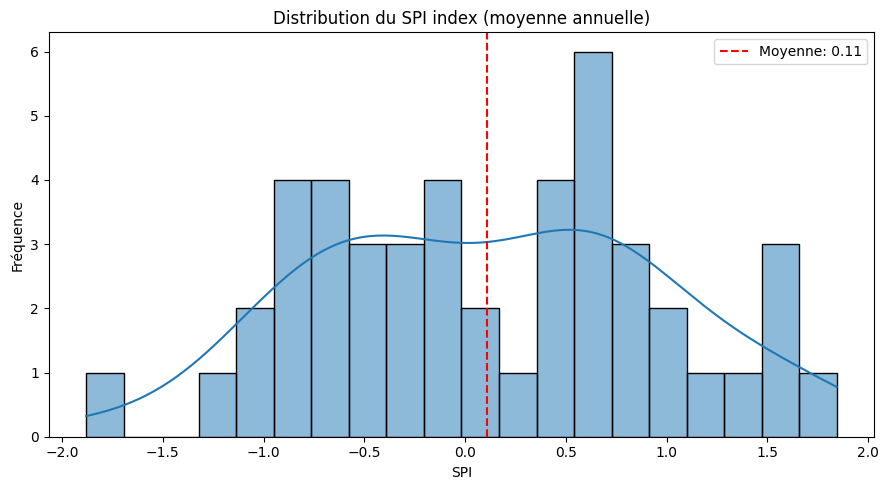

count    46.000000
mean      0.111135
std       0.856195
min      -1.880435
25%      -0.594034
50%       0.041024
75%       0.675057
max       1.844582
Name: SPI, dtype: float64


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution du SPI index annuel
plt.figure(figsize=(9, 5))
sns.histplot(SPI_index['SPI'].dropna(), bins=20, kde=True)
plt.axvline(SPI_index['SPI'].mean(), color='red', linestyle='--', label=f"Moyenne: {SPI_index['SPI'].mean():.2f}")
plt.title('Distribution du SPI index (moyenne annuelle)')
plt.xlabel('SPI')
plt.ylabel('Fréquence')
plt.legend()
plt.tight_layout()
plt.show()

print(SPI_index['SPI'].describe())

On prend comme treshold -0.5 pour rester cohérent avec l'article Probabilistic estimates of drought impacts on agricultural production et puisque le premier quartile de la distribution des valeurs de l'indicateur de sécheresse est égal à -0.6, ce qui est similaire.

✔ data/spi_annuel_depuis_SPI_csv.png sauvegardé


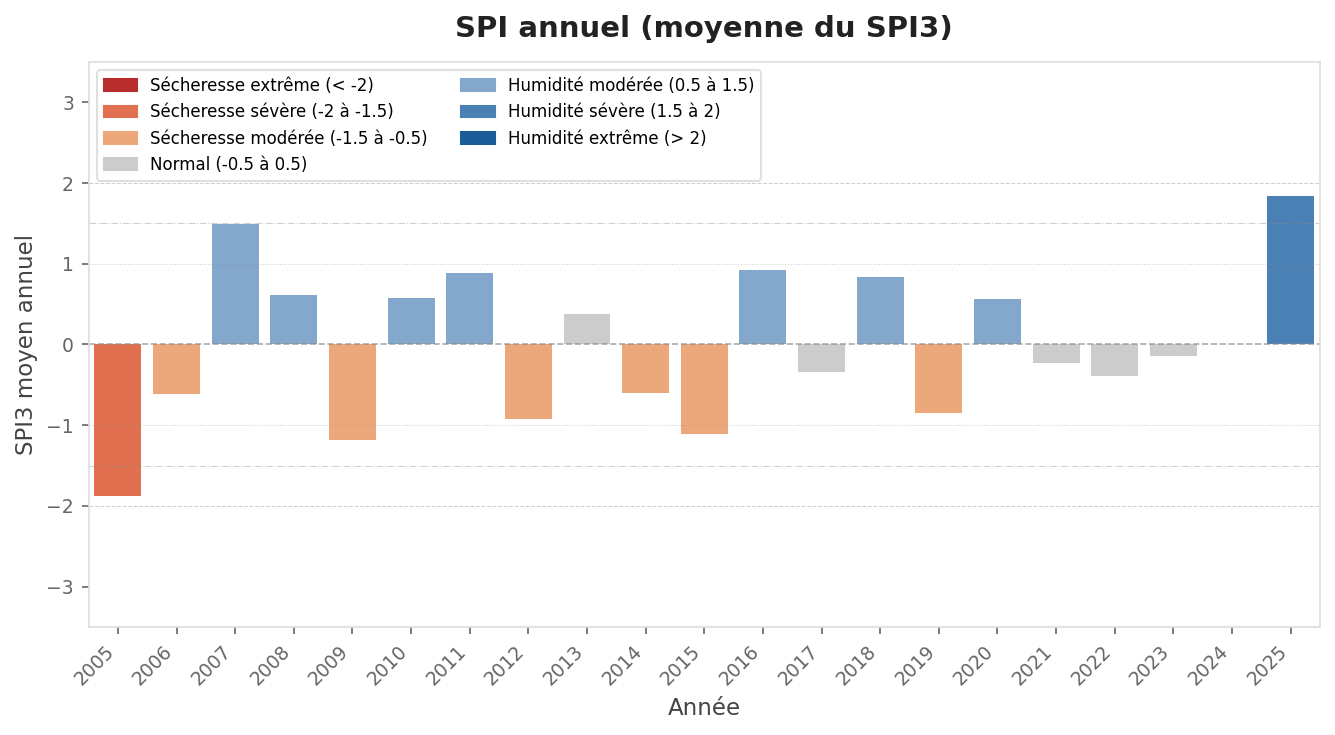


Done.
        date  spi_annuel  year
0 2005-01-01   -1.880435  2005
1 2006-01-01   -0.612123  2006
2 2007-01-01    1.496556  2007
3 2008-01-01    0.611453  2008
4 2009-01-01   -1.181186  2009


In [16]:
"""
Visualisation du SPI annuel à partir de data/SPI.csv
Le fichier contient: time, lat, lon, SPI3 (3 mois).
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ─────────────────────────────────────────────
# PARAMÈTRES
# ─────────────────────────────────────────────
FICHIER_SPI = "data/SPI.csv"
DPI = 150

# Catégories SPI (OMM)
BINS = [-np.inf, -2.0, -1.5, -0.5, 0.5, 1.5, 2.0, np.inf]
COLORS = ["#B72D2D", "#E07050", "#ECA87A", "#CCCCCC", "#83A8CC", "#4A80B4", "#1B5C99"]
LABELS = [
    "Sécheresse extrême (< -2)",
    "Sécheresse sévère (-2 à -1.5)",
    "Sécheresse modérée (-1.5 à -0.5)",
    "Normal (-0.5 à 0.5)",
    "Humidité modérée (0.5 à 1.5)",
    "Humidité sévère (1.5 à 2)",
    "Humidité extrême (> 2)",
]

def couleur_spi(valeur):
    for i in range(len(BINS) - 1):
        if BINS[i] <= valeur < BINS[i + 1]:
            return COLORS[i]
    return COLORS[3]

# ─────────────────────────────────────────────
# CHARGEMENT + AGRÉGATION ANNUELLE (via colonne date)
# ─────────────────────────────────────────────
df = pd.read_csv(FICHIER_SPI)
df["time"] = pd.to_datetime(df["time"], errors="coerce")
df = df.dropna(subset=["time", "SPI3"])
df = df[df["time"].dt.year >= 2005]

df["date"] = df["time"].dt.to_period("Y").dt.to_timestamp()

df_a = df.groupby("date", as_index=False)["SPI3"].mean()
df_a = df_a.rename(columns={"SPI3": "spi_annuel"})
df_a["year"] = df_a["date"].dt.year

# ─────────────────────────────────────────────
# FIGURE : SPI ANNUEL
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5), dpi=DPI)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

colors_a = [couleur_spi(v) for v in df_a["spi_annuel"]]
ax.bar(df_a["year"], df_a["spi_annuel"], color=colors_a, width=0.8, linewidth=0)

# Ligne zéro + seuils
ax.axhline(0, color="#888888", linewidth=0.8, linestyle="--", alpha=0.7)
for seuil, ls in [(-1, ":"), (-1.5, "-."), (-2, "--"), (1, ":"), (1.5, "-."), (2, "--")]:
    ax.axhline(seuil, color="#888888", linewidth=0.5, linestyle=ls, alpha=0.4)

ax.set_xlim(df_a["year"].min() - 0.5, df_a["year"].max() + 0.5)
ax.set_ylim(-3.5, 3.5)
ax.set_xticks(df_a["year"])
ax.set_xticklabels(df_a["year"], rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Année", fontsize=11, color="#444")
ax.set_ylabel("SPI3 moyen annuel", fontsize=11, color="#444")
ax.set_title("SPI annuel (moyenne du SPI3)", fontsize=14, fontweight="bold", pad=12, color="#222")

ax.tick_params(colors="#666", labelsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor("#dddddd")

patches = [mpatches.Patch(color=c, label=l) for c, l in zip(COLORS, LABELS)]
ax.legend(
    handles=patches,
    loc="upper left",
    fontsize=8,
    framealpha=0.9,
    edgecolor="#dddddd",
    ncol=2,
)

plt.tight_layout()
plt.savefig("data/spi_annuel_depuis_SPI_csv.png", dpi=DPI, bbox_inches="tight")
print("✔ data/spi_annuel_depuis_SPI_csv.png sauvegardé")
plt.show()

print("\nDone.")
print(df_a.head())


The annual mean of SPI3 does not suggest a simple monotonic increase in drought exposure over time. Instead, it points to strong interannual variability, with alternating dry and wet years throughout the sample. Several years stand out as clearly dry, notably 2005 and then again around 2012–2015, which appears to be the most sustained relatively dry phase in the series. At the same time, this pattern is repeatedly interrupted by wetter years such as 2007, 2008, 2010, 2011, 2016, 2018, 2020, and especially 2025. Overall, the series suggests recurrent exposure to drought episodes rather than a continuous worsening trend. That said, because this indicator is based on the annual average of SPI3, it smooths short-term and seasonal extremes: a year with severe summer drought may still appear close to normal if wetter conditions prevail during the rest of the year. As a result, the figure is best interpreted as showing broad annual hydro-climatic fluctuations rather than the full intensity or persistence of drought conditions.

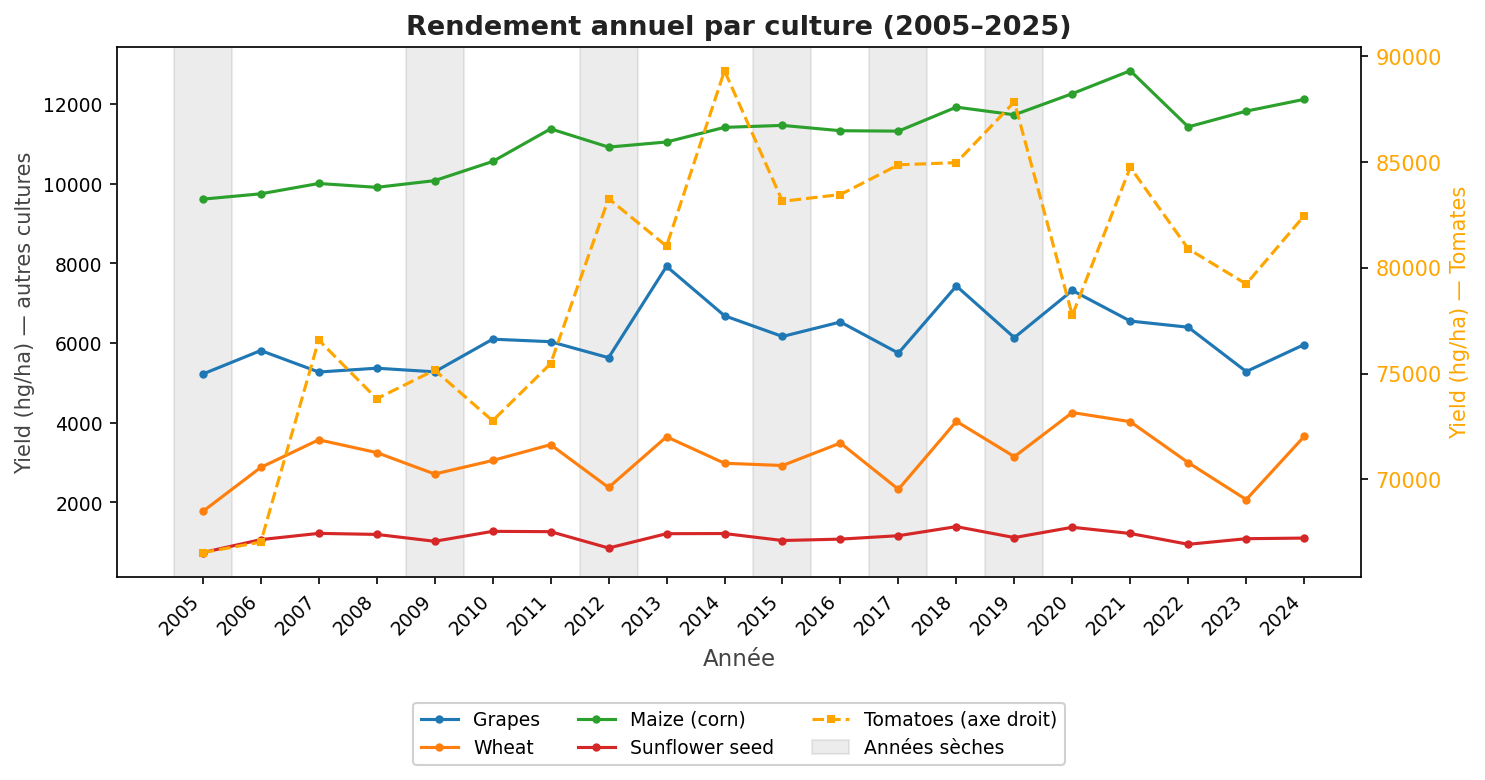

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

crops_left = {
    "Grapes": grapes,
    "Wheat": wheat,
    "Maize (corn)": maize,
    "Sunflower seed": sunflower,
}

dry_years = [2005, 2009, 2012, 2015, 2017, 2019]

fig, ax1 = plt.subplots(figsize=(10, 5), dpi=150)
ax2 = ax1.twinx()

# Bandes grises pour années sèches (en arrière-plan)
for yr in dry_years:
    ax1.axvspan(yr - 0.5, yr + 0.5, color="gray", alpha=0.15, zorder=0)

# Cultures sur axe gauche
for name, df_crop in crops_left.items():
    df_filtered = df_crop[df_crop["date"] >= 2005].dropna(subset=["Yield"])
    ax1.plot(df_filtered["date"], df_filtered["Yield"], marker="o", markersize=3, linewidth=1.5, label=name)

# Tomates sur axe droit
df_tom = tomatoes[tomatoes["date"] >= 2005].dropna(subset=["Yield"])
ax2.plot(df_tom["date"], df_tom["Yield"], marker="s", markersize=3, linewidth=1.5,
         color="orange", linestyle="--", label="Tomatoes (axe droit)")

# Ticks années entières
all_years = sorted(grapes[grapes["date"] >= 2005]["date"].unique())
ax1.set_xticks(all_years)
ax1.set_xticklabels(all_years, rotation=45, ha="right", fontsize=8)

# Axes
ax1.set_xlabel("Année", fontsize=11, color="#444")
ax1.set_ylabel("Yield (hg/ha) — autres cultures", fontsize=10, color="#444")
ax2.set_ylabel("Yield (hg/ha) — Tomates", fontsize=10, color="orange")
ax2.tick_params(axis="y", labelcolor="orange")

ax1.set_title("Rendement annuel par culture (2005–2025)", fontsize=13, fontweight="bold", color="#222")

# Légende combinée — placée en dehors du graphique, en bas
dry_patch = mpatches.Patch(color="gray", alpha=0.15, label="Années sèches")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + [dry_patch], labels1 + labels2 + ["Années sèches"], fontsize=9, framealpha=0.9,
           loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=3)

ax1.tick_params(labelsize=9)
for spine in ax1.spines.values():
    spine.set_edgecolor("#dddddd")

plt.tight_layout()
plt.subplots_adjust(bottom=0.22)
plt.show()
